In [1]:
import torch, os
os.environ["CUDA_VISIBLE_DEVICES"] = "2" 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 設定繪圖風格 (讓圖表適合放進論文)
sns.set(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['font.sans-serif'] = ['Arial'] # 或設定支援中文的字體
plt.rcParams['axes.unicode_minus'] = False

# 1. 讀取資料
df = pd.read_csv('final_dataset.csv')

#刪除max_resp_rate的異常值
df = df[df['max_resp_rate'] < 150]

# 2. 定義變數類別 (方便後續批次處理)
num_cols = ['age', 'min_map', 'max_resp_rate', 'los'] # 數值型
cat_cols = ['gender_code', 'is_intubated', 'target_long_stay'] # 類別型

# 3. 增加一個「文本長度」特徵 (論文中可以討論文本長度是否跟病情嚴重度有關)
df['text_length'] = df['text'].astype(str).apply(len)
num_cols.append('text_length')

print("=== 資料集概況 ===")
print(f"總筆數: {df.shape[0]}")
print(f"特徵數: {df.shape[1]}")
print("-" * 30)
print("目標變數分佈 (Class Balance):")
print(df['target_long_stay'].value_counts(normalize=True).rename({0: 'Short Stay (≤7d)', 1: 'Long Stay (>7d)'}))

=== 資料集概況 ===
總筆數: 34836
特徵數: 13
------------------------------
目標變數分佈 (Class Balance):
target_long_stay
Short Stay (≤7d)    0.892697
Long Stay (>7d)     0.107303
Name: proportion, dtype: float64


In [13]:
df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'intime', 'los', 'target_long_stay',
       'age', 'gender_code', 'text', 'is_intubated', 'min_map',
       'max_resp_rate', 'text_length'],
      dtype='object')

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

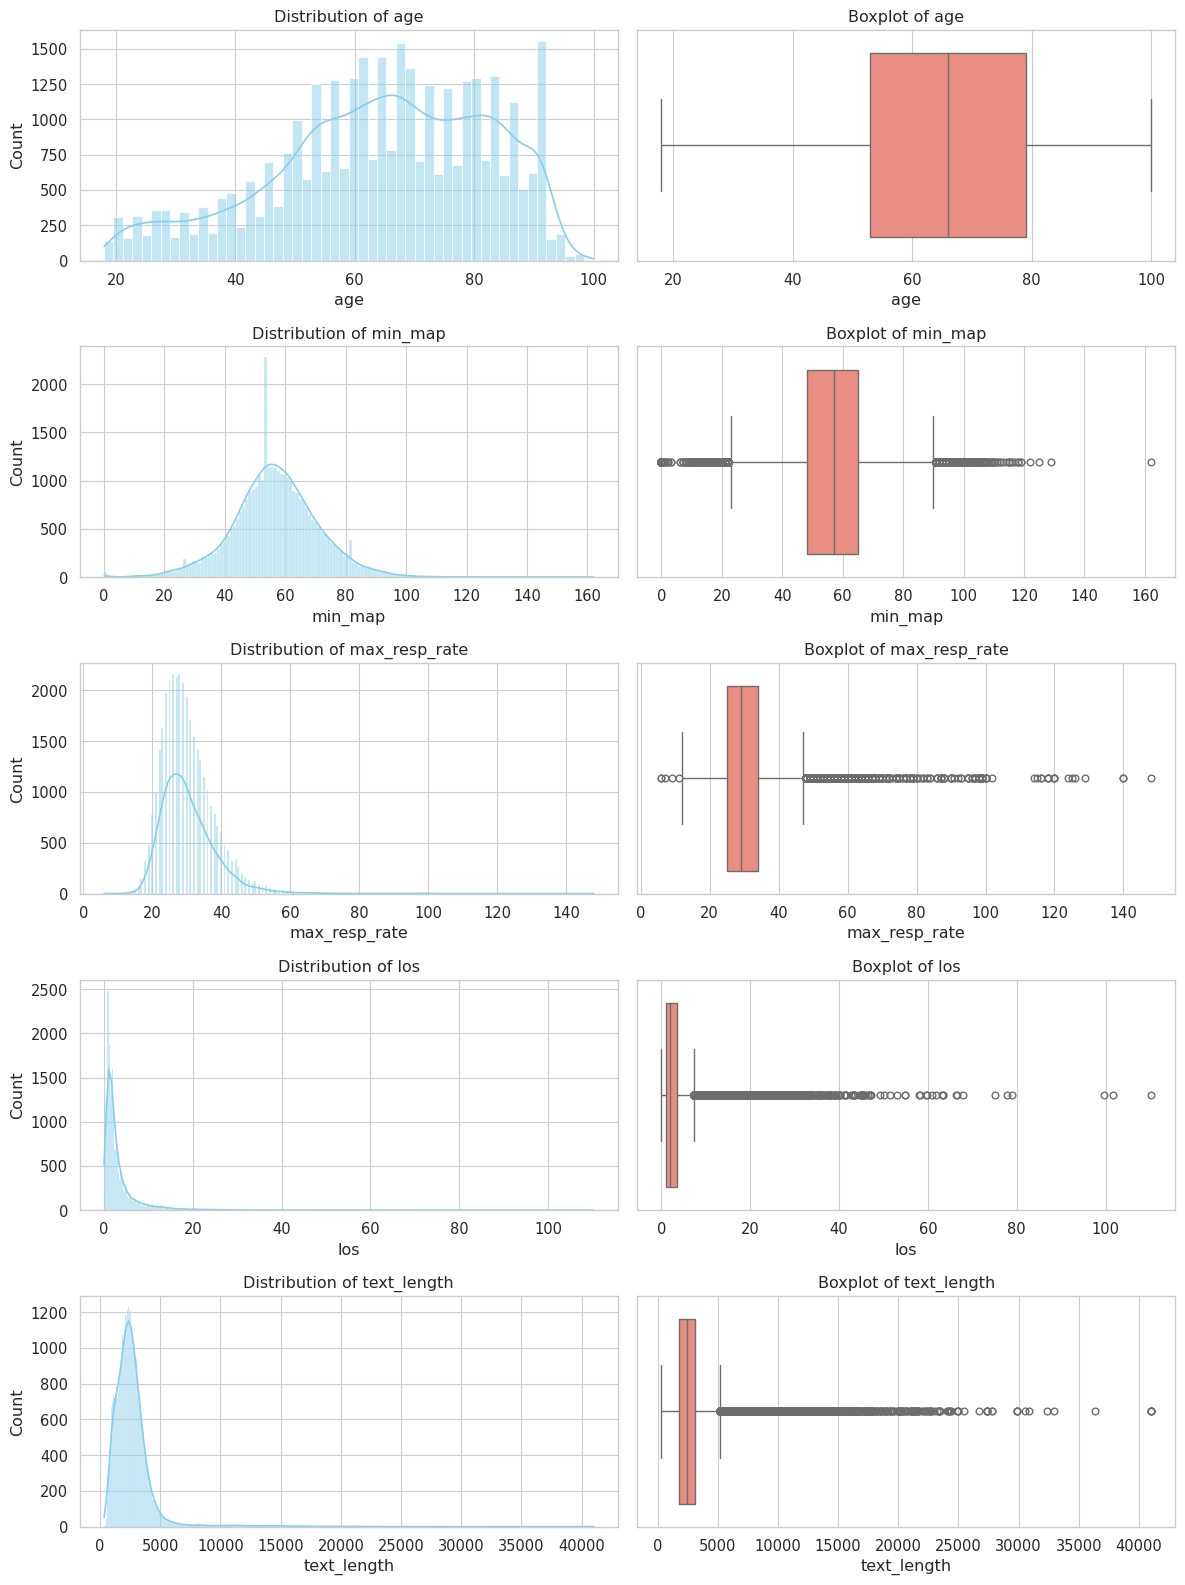

=== 數值變數描述性統計 ===
                 count         mean          std        min          25%  \
age            34836.0    64.153979    18.013272   18.00000    53.000000   
min_map        34836.0    56.774007    14.083374    0.00000    48.000000   
max_resp_rate  34836.0    30.429871     8.401562    6.00000    25.000000   
los            34836.0     3.306767     4.623391    0.00125     1.020729   
text_length    34836.0  2713.004564  2062.719173  326.00000  1741.000000   

                       50%          75%          max  
age              66.000000    79.000000    100.00000  
min_map          57.000000    65.000000    162.00000  
max_resp_rate    29.000000    34.000000    148.00000  
los               1.859959     3.548785    110.23228  
text_length    2409.000000  3120.000000  41000.00000  


In [4]:
# 繪製數值變數的直方圖 (Histogram) 與 箱型圖 (Boxplot)
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 16))

for i, col in enumerate(num_cols):
    # 直方圖 (看分佈形狀)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # 箱型圖 (看異常值 outliers)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# 顯示描述性統計量
print("=== 數值變數描述性統計 ===")
print(df[num_cols].describe().T)

/tmp/ipykernel_3303816/2779352043.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_long_stay', y=col, data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3303816/2779352043.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Short Stay', 'Long Stay'])
/tmp/ipykernel_3303816/2779352043.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target_long_stay', y=col, data=df, ax=axes[i], palette="Set2")
/tmp/ipykernel_3303816/2779352043.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

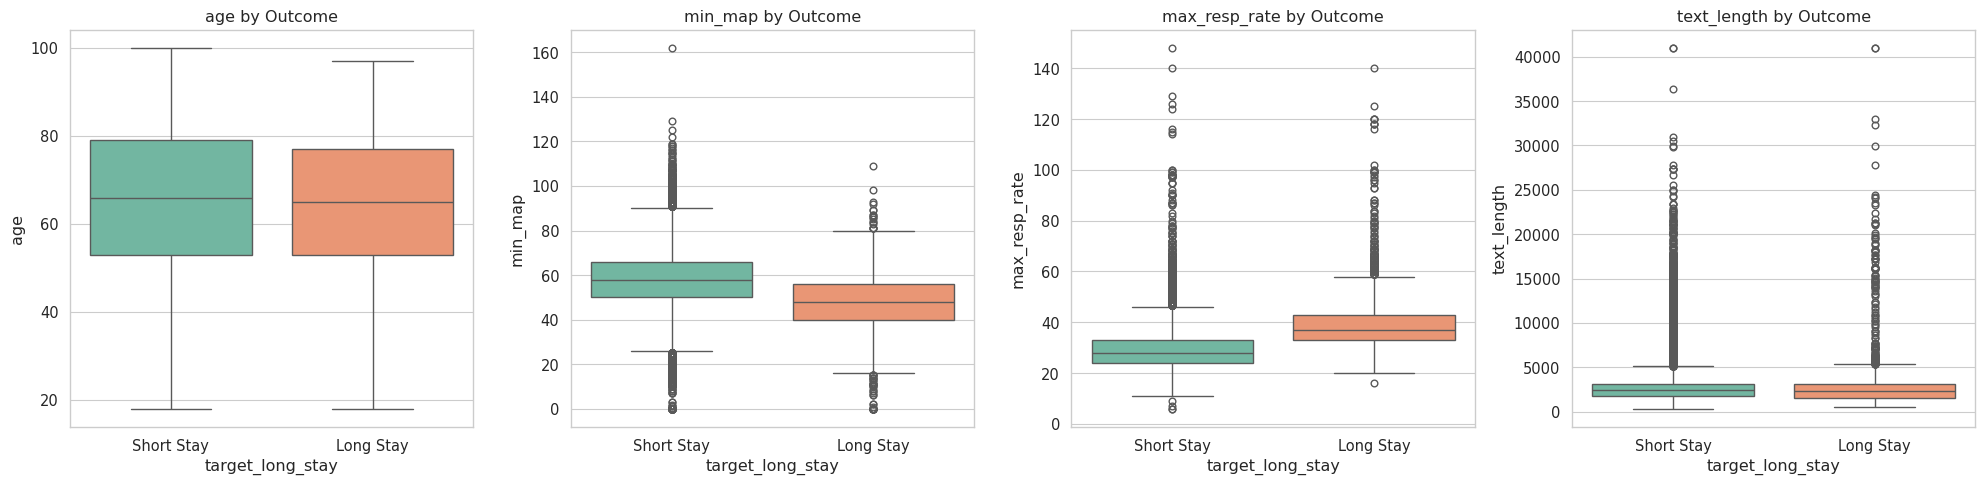

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

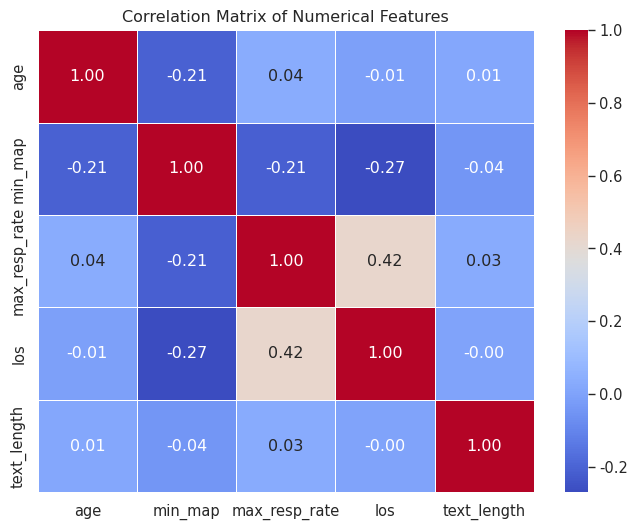

In [5]:
# 1. 數值變數 vs Target (Boxplot 比較)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
cols_to_compare = ['age', 'min_map', 'max_resp_rate', 'text_length']

for i, col in enumerate(cols_to_compare):
    sns.boxplot(x='target_long_stay', y=col, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f'{col} by Outcome')
    axes[i].set_xticklabels(['Short Stay', 'Long Stay'])

plt.tight_layout()
plt.show()

# 2. 相關性矩陣 (Correlation Heatmap)
# 檢查有沒有共線性問題 (Multicollinearity)
plt.figure(figsize=(8, 6))
corr_matrix = df[['age', 'min_map', 'max_resp_rate', 'los', 'text_length']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [6]:
def generate_table1(df, target_col):
    """
    自動生成包含 P-value 的 Table 1
    """
    variables = []
    long_stay = df[df[target_col] == 1]
    short_stay = df[df[target_col] == 0]
    
    # 1. 處理數值變數 (Mean ± SD, T-test)
    num_features = ['age', 'min_map', 'max_resp_rate', 'text_length']
    for col in num_features:
        # 計算統計量
        mean_long = long_stay[col].mean()
        sd_long = long_stay[col].std()
        mean_short = short_stay[col].mean()
        sd_short = short_stay[col].std()
        
        # 進行 T-test
        t_stat, p_val = stats.ttest_ind(long_stay[col].dropna(), short_stay[col].dropna(), equal_var=False)
        
        variables.append({
            'Feature': f"{col} (Mean ± SD)",
            'Short Stay (N={len(short_stay)})': f"{mean_short:.2f} ± {sd_short:.2f}",
            'Long Stay (N={len(long_stay)})': f"{mean_long:.2f} ± {sd_long:.2f}",
            'P-value': p_val
        })
        
    # 2. 處理類別變數 (Count (%), Chi-square)
    cat_features = ['gender_code', 'is_intubated']
    for col in cat_features:
        # 計算 Confusion Matrix
        contingency_table = pd.crosstab(df[col], df[target_col])
        
        # 進行卡方檢定
        chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
        
        # 針對 "是 (1)" 的比例做報告
        count_short = short_stay[col].sum()
        pct_short = (count_short / len(short_stay)) * 100
        count_long = long_stay[col].sum()
        pct_long = (count_long / len(long_stay)) * 100
        
        variables.append({
            'Feature': f"{col}=1 (n, %)",
            'Short Stay (N={len(short_stay)})': f"{count_short} ({pct_short:.1f}%)",
            'Long Stay (N={len(long_stay)})': f"{count_long} ({pct_long:.1f}%)",
            'P-value': p_val
        })

    # 轉成 DataFrame 並格式化 P-value
    table1 = pd.DataFrame(variables)
    
    # 將 P-value < 0.001 標示出來
    def format_p(p):
        if p < 0.001: return "< 0.001 ***"
        if p < 0.05: return f"{p:.3f} *"
        return f"{p:.3f}"
        
    table1['P-value'] = table1['P-value'].apply(format_p)
    
    return table1

# 執行並顯示結果
table1_df = generate_table1(df, 'target_long_stay')
print("\n=== Table 1: Baseline Characteristics by ICU Length of Stay ===")
display(table1_df)

# 匯出成 Excel 方便貼到 Word
table1_df.to_csv('Table1_Analysis.csv', index=False)
print("Table 1 已儲存為 'Table1_Analysis.csv'")


=== Table 1: Baseline Characteristics by ICU Length of Stay ===


,Feature,Short Stay (N={len(short_stay)}),Long Stay (N={len(long_stay)}),P-value
0,age (Mean ± SD),64.24 ± 18.16,63.43 ± 16.75,0.006 *
1,min_map (Mean ± SD),57.85 ± 13.86,47.80 ± 12.66,< 0.001 ***
2,max_resp_rate (Mean ± SD),29.39 ± 7.48,39.07 ± 10.40,< 0.001 ***
3,text_length (Mean ± SD),2711.67 ± 1986.28,2724.10 ± 2613.70,0.779
4,"gender_code=1 (n, %)",16860 (54.2%),2178 (58.3%),< 0.001 ***
5,"is_intubated=1 (n, %)",2074 (6.7%),1601 (42.8%),< 0.001 ***


Table 1 已儲存為 'Table1_Analysis.csv'


/tmp/ipykernel_3303816/357389744.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")


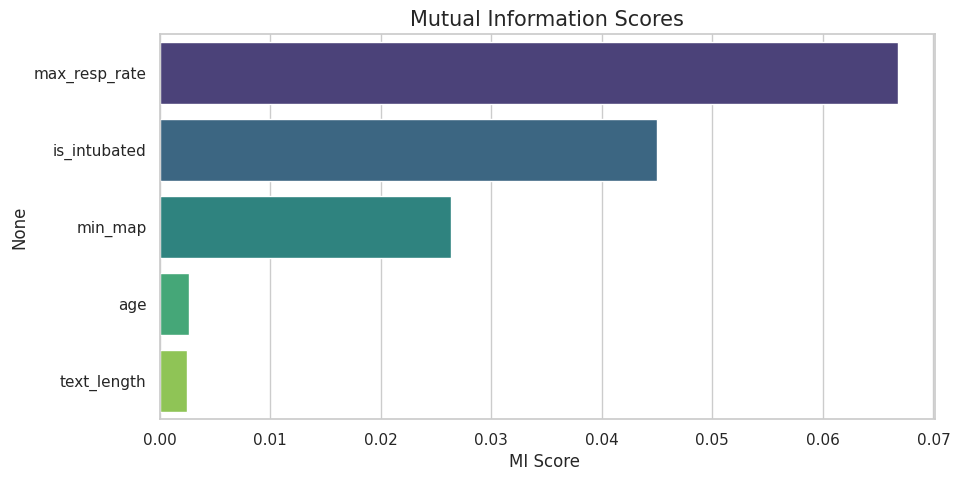

解讀：MI Score 越高，代表該變數包含越多關於 Target 的資訊（包含非線性關係）。


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# 設定繪圖風格
sns.set(style="whitegrid")

# 1. 準備資料 (假設你的 dataframe 是 df)
# 確保沒有 NaN，因為 sklearn 無法處理 NaN
features = ['age', 'min_map', 'max_resp_rate', 'text_length', 'is_intubated']
target = 'target_long_stay'

# 簡單的dropna以防萬一 (實務上你應該已經補值過了)
X = df[features].dropna()
y = df.loc[X.index, target]

# 2. 計算 Mutual Information
# discrete_features: 指示哪些特徵是離散的 (如 is_intubated)
discrete_mask = [f == 'is_intubated' for f in features]

mi_scores = mutual_info_classif(X, y, discrete_features=discrete_mask, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# 3. 繪圖
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
plt.title("Mutual Information Scores", fontsize=15)
plt.xlabel("MI Score ")
plt.show()

print("解讀：MI Score 越高，代表該變數包含越多關於 Target 的資訊（包含非線性關係）。")

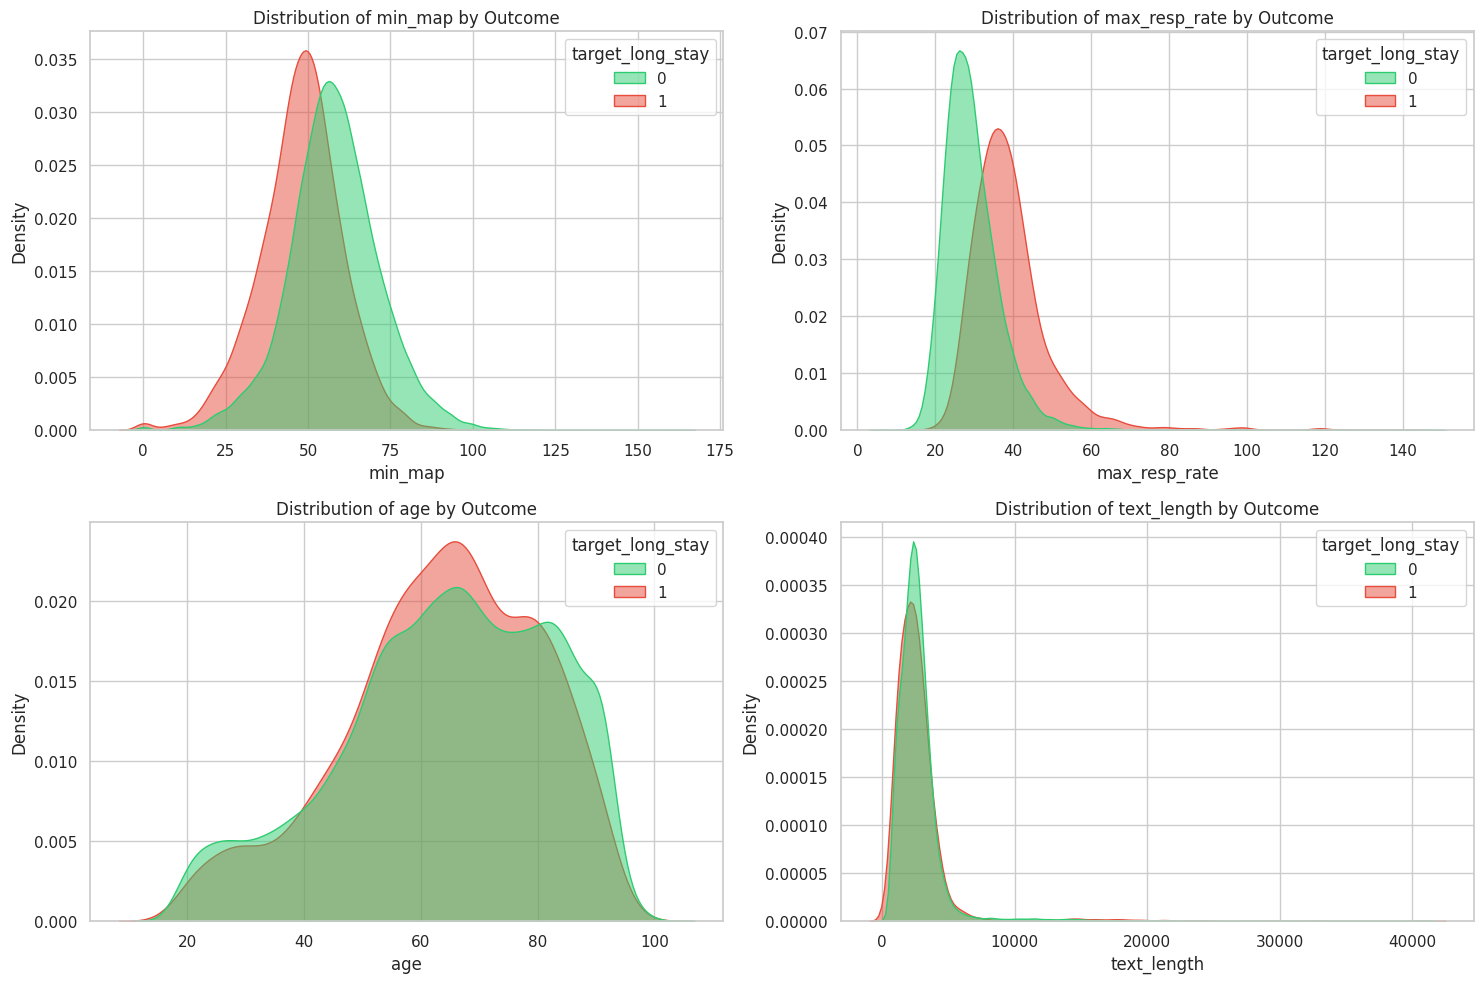

解讀：觀察紅色 (Long Stay) 與綠色 (Short Stay) 的山峰是否錯開。
重點觀察：min_map 的紅色山峰是否明顯偏左 (低血壓)？max_resp_rate 清洗後是否出現差異？


In [10]:
# 選擇數值型特徵
num_features = ['min_map', 'max_resp_rate', 'age', 'text_length']

plt.figure(figsize=(15, 10))

for i, col in enumerate(num_features):
    plt.subplot(2, 2, i+1)
    
    # 畫出兩類的密度分佈
    sns.kdeplot(data=df, x=col, hue='target_long_stay', 
                fill=True, common_norm=False, palette=["#2ecc71", "#e74c3c"], alpha=0.5)
    
    plt.title(f"Distribution of {col} by Outcome", fontsize=12)
    plt.xlabel(col)
    
plt.tight_layout()
plt.show()

print("解讀：觀察紅色 (Long Stay) 與綠色 (Short Stay) 的山峰是否錯開。")
print("重點觀察：min_map 的紅色山峰是否明顯偏左 (低血壓)？max_resp_rate 清洗後是否出現差異？")

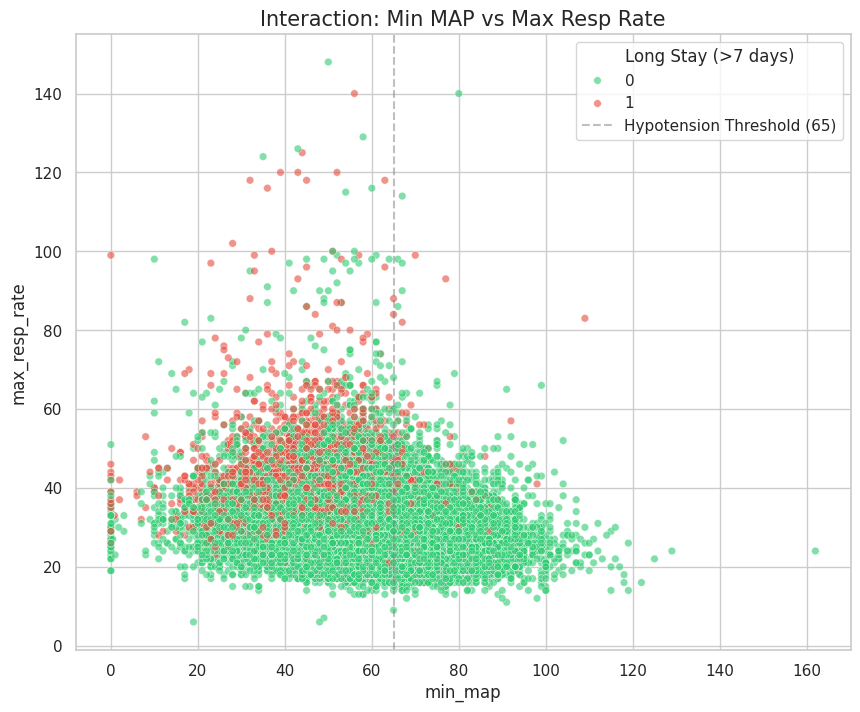

解讀：
1. 尋找紅點聚集區：是否集中在左上角 (低血壓 + 呼吸快)？
2. 如果能畫出一條斜線把紅綠分開，代表這兩個變數做『線性組合』或是『交互作用』會非常有效。


In [11]:
plt.figure(figsize=(10, 8))

# 使用散佈圖觀察兩個生理指標的聯合分佈
sns.scatterplot(
    data=df, 
    x='min_map', 
    y='max_resp_rate', 
    hue='target_long_stay', 
    alpha=0.6, 
    palette={0: "#2ecc71", 1: "#e74c3c"}, # 0: Short(綠), 1: Long(紅)
    s=30
)

plt.title("Interaction: Min MAP vs Max Resp Rate", fontsize=15)
plt.axvline(65, color='gray', linestyle='--', alpha=0.5, label='Hypotension Threshold (65)')
plt.legend(title='Long Stay (>7 days)')
plt.show()

print("解讀：")
print("1. 尋找紅點聚集區：是否集中在左上角 (低血壓 + 呼吸快)？")
print("2. 如果能畫出一條斜線把紅綠分開，代表這兩個變數做『線性組合』或是『交互作用』會非常有效。")